In [1]:
import numpy as np
from astropy.io import fits
import stpsf
from astropy.nddata import Cutout2D
from correction_script import find_stars, star_check, better_psf_fitting, plot_data_sim_comparison, sigma_clip

/home/wesley/Desktop/JWST_REU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
path_image = "/home/wesley/Desktop/JWST_REU/2025_data/"
file = '/home/wesley/Desktop/JWST_REU/2025_data/nan-rm-jwst-2025-f444w-f470n.fits'

In [3]:
hdu = fits.open((path_image + 'nan-rm-jwst-2025-f444w-f470n.fits'))

83.81229107686516 -4.998224758110513
INFO: Query finished. [astroquery.utils.tap.core]


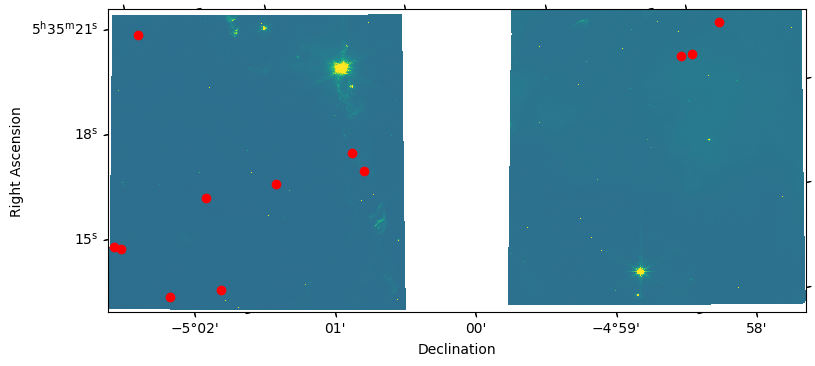

In [4]:
ra_center = hdu[1].header['CRVAL1']
dec_center = hdu[1].header['CRVAL2']
print (ra_center, dec_center)
size_deg = .1
image = hdu[1].data
header = hdu[1].header

x_coords, y_coords, gaia_star_field = find_stars(ra_center, dec_center, size_deg, image, header)

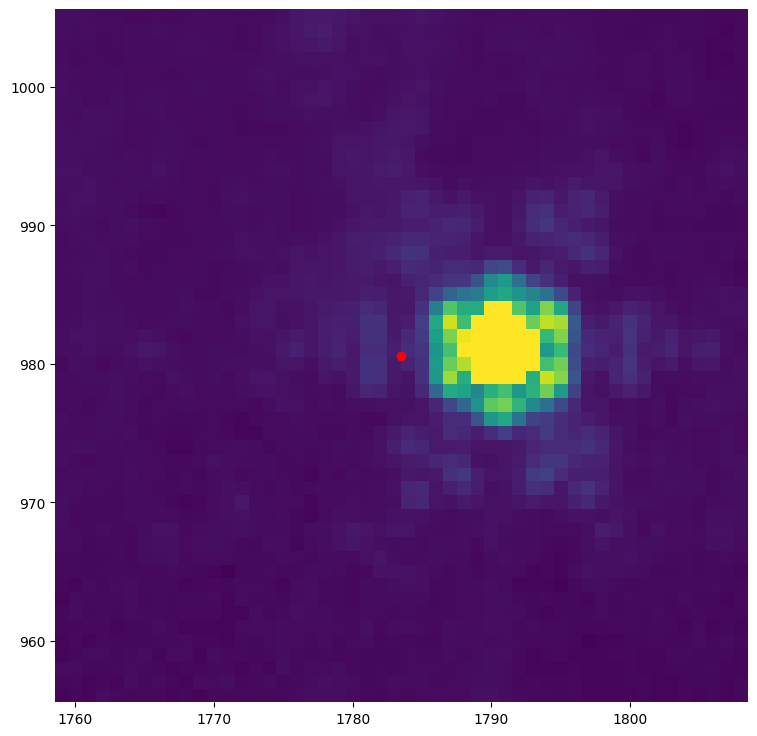

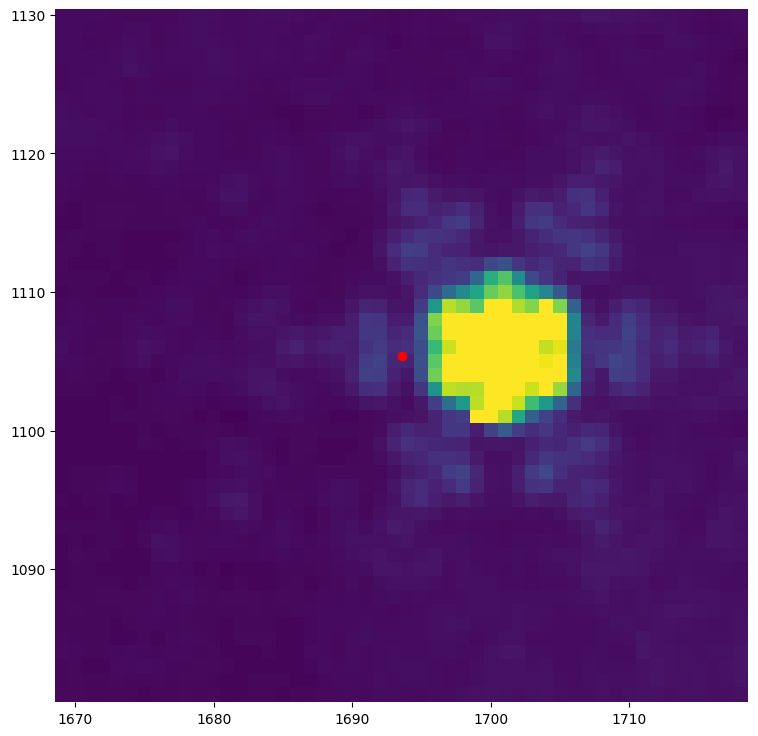

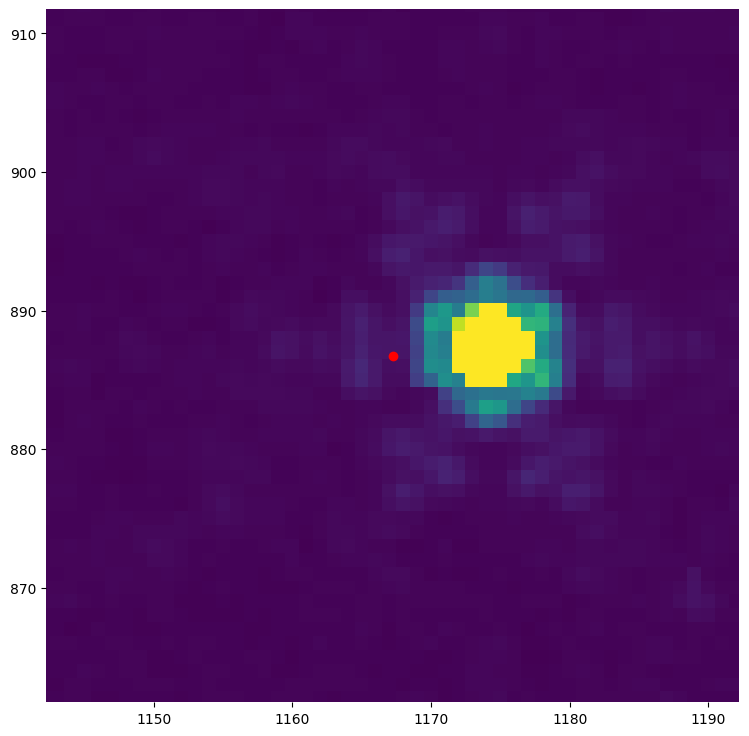

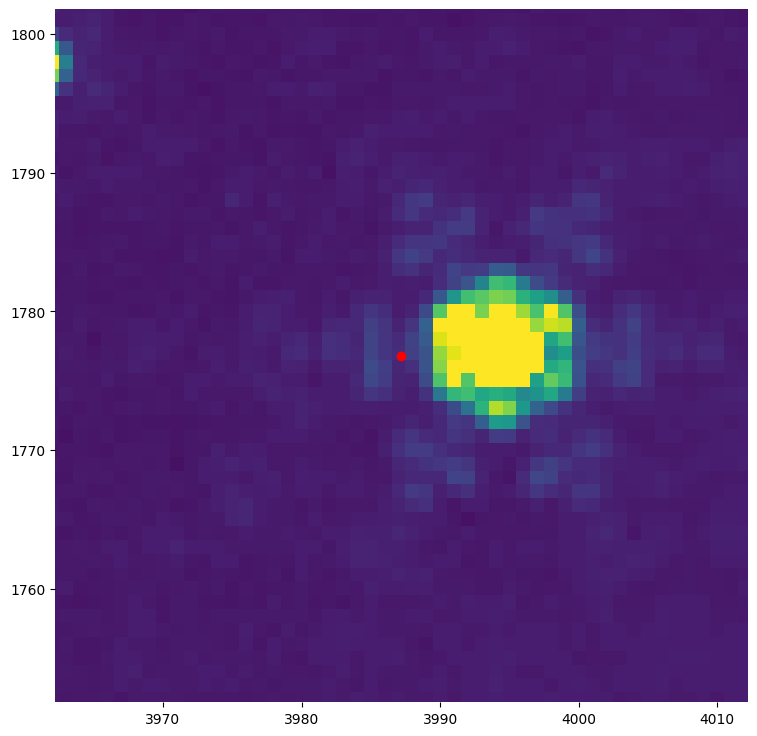

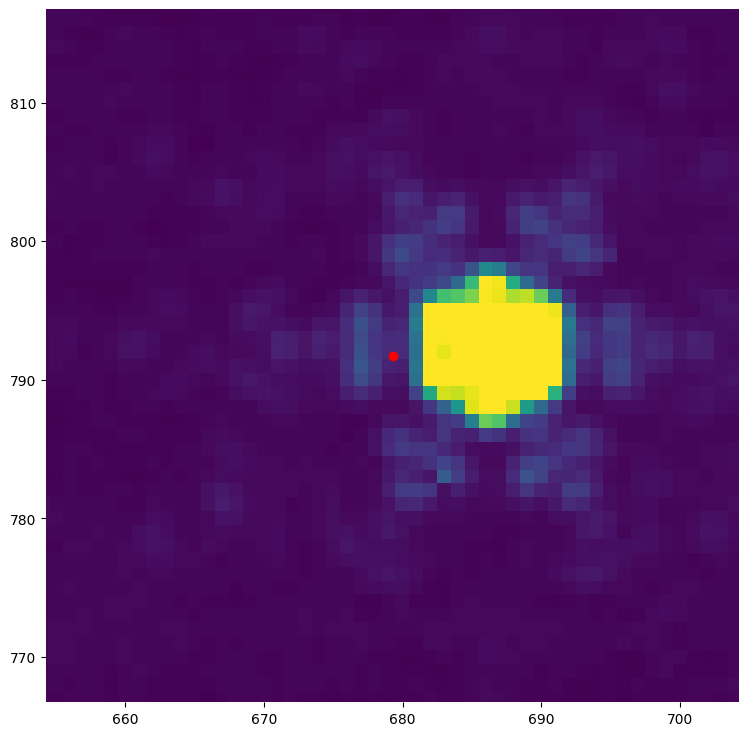

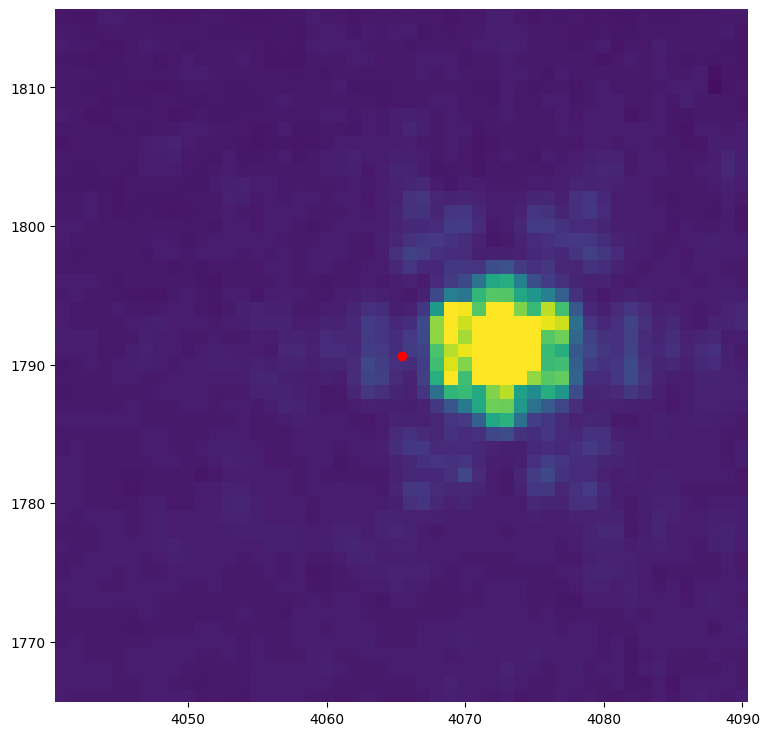

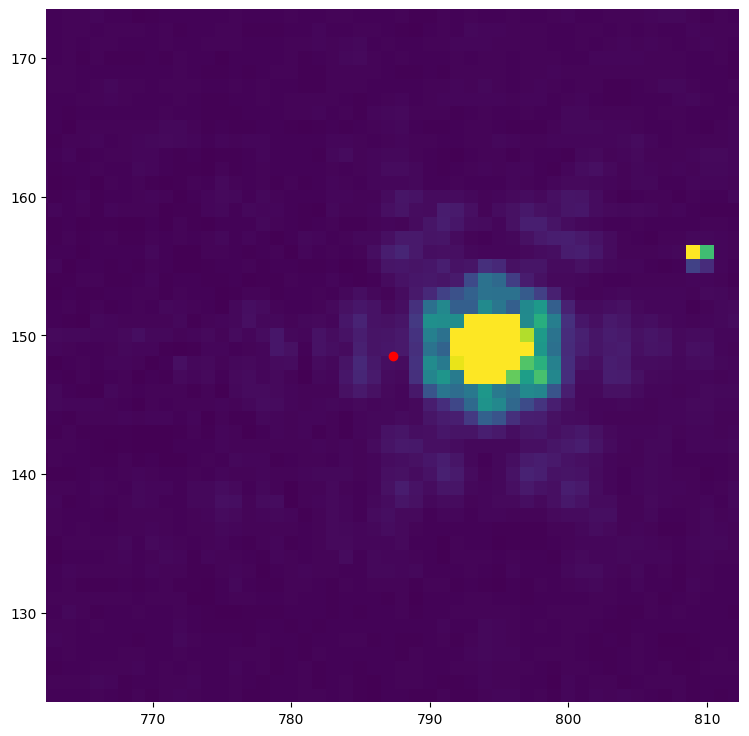

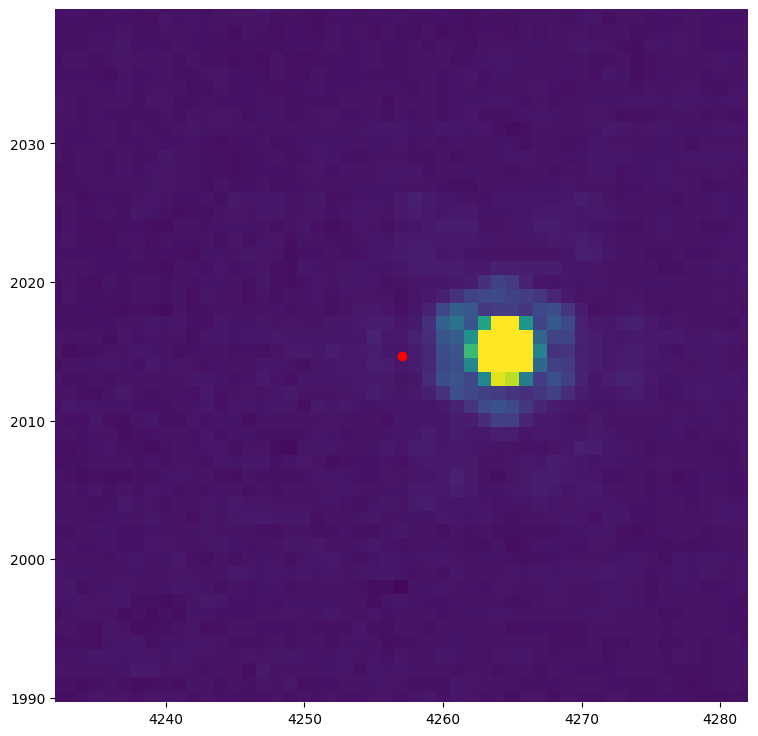

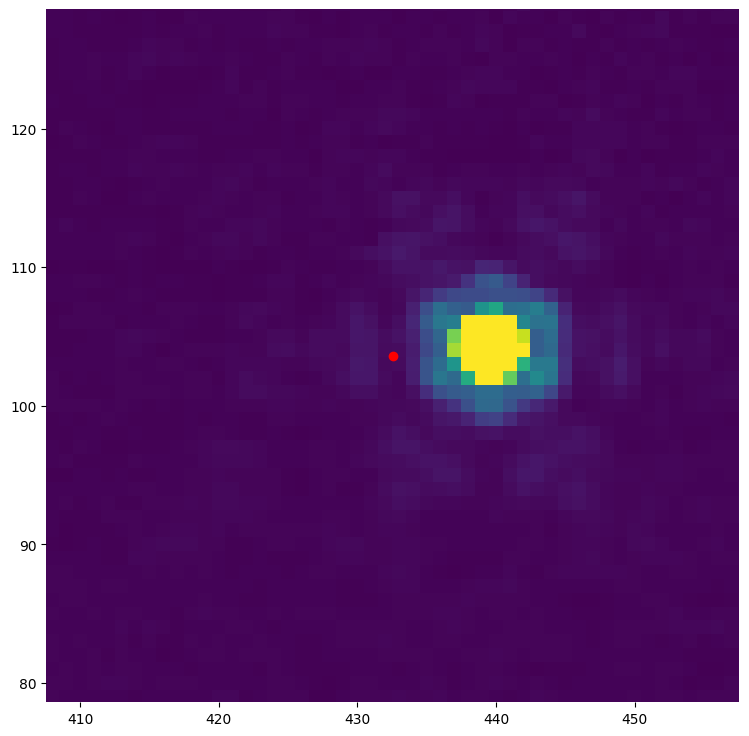

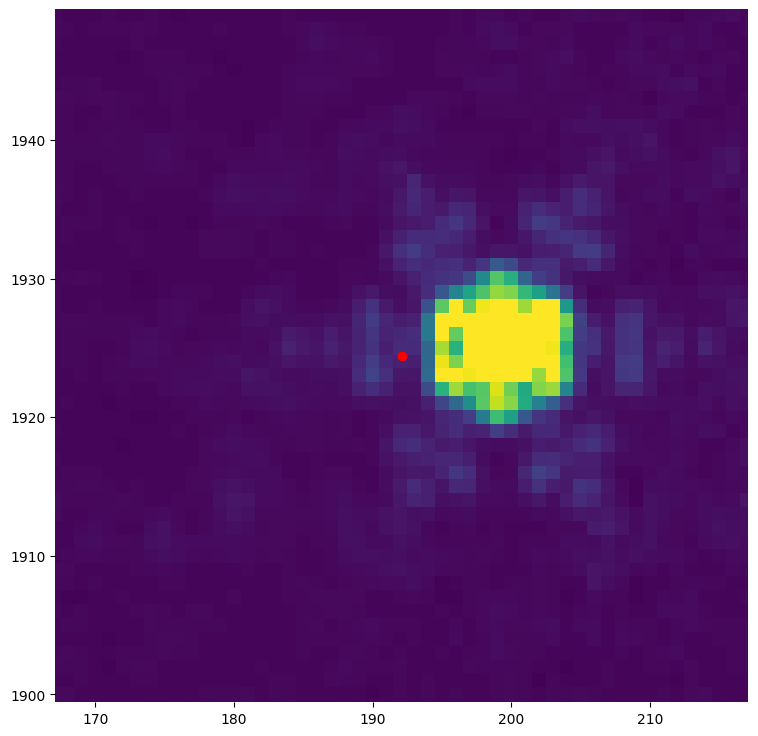

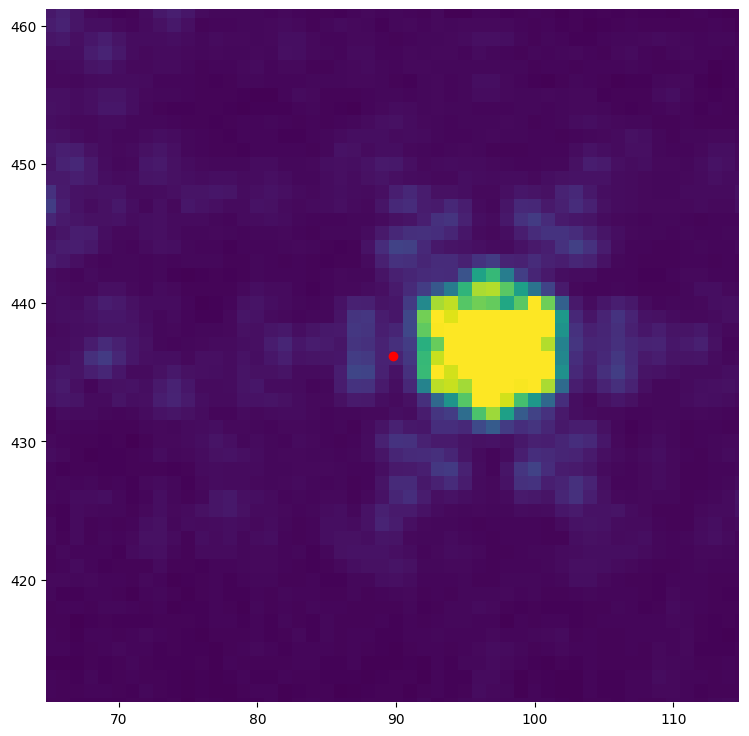

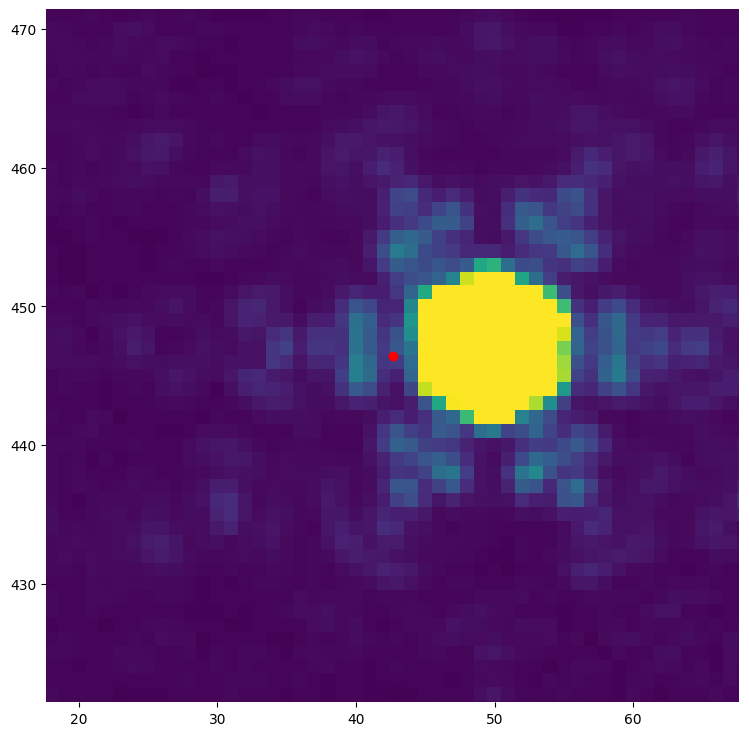

In [5]:
star_check(image, header, gaia_star_field)

100%|██████████| 90601/90601 [00:12<00:00, 6969.71it/s]


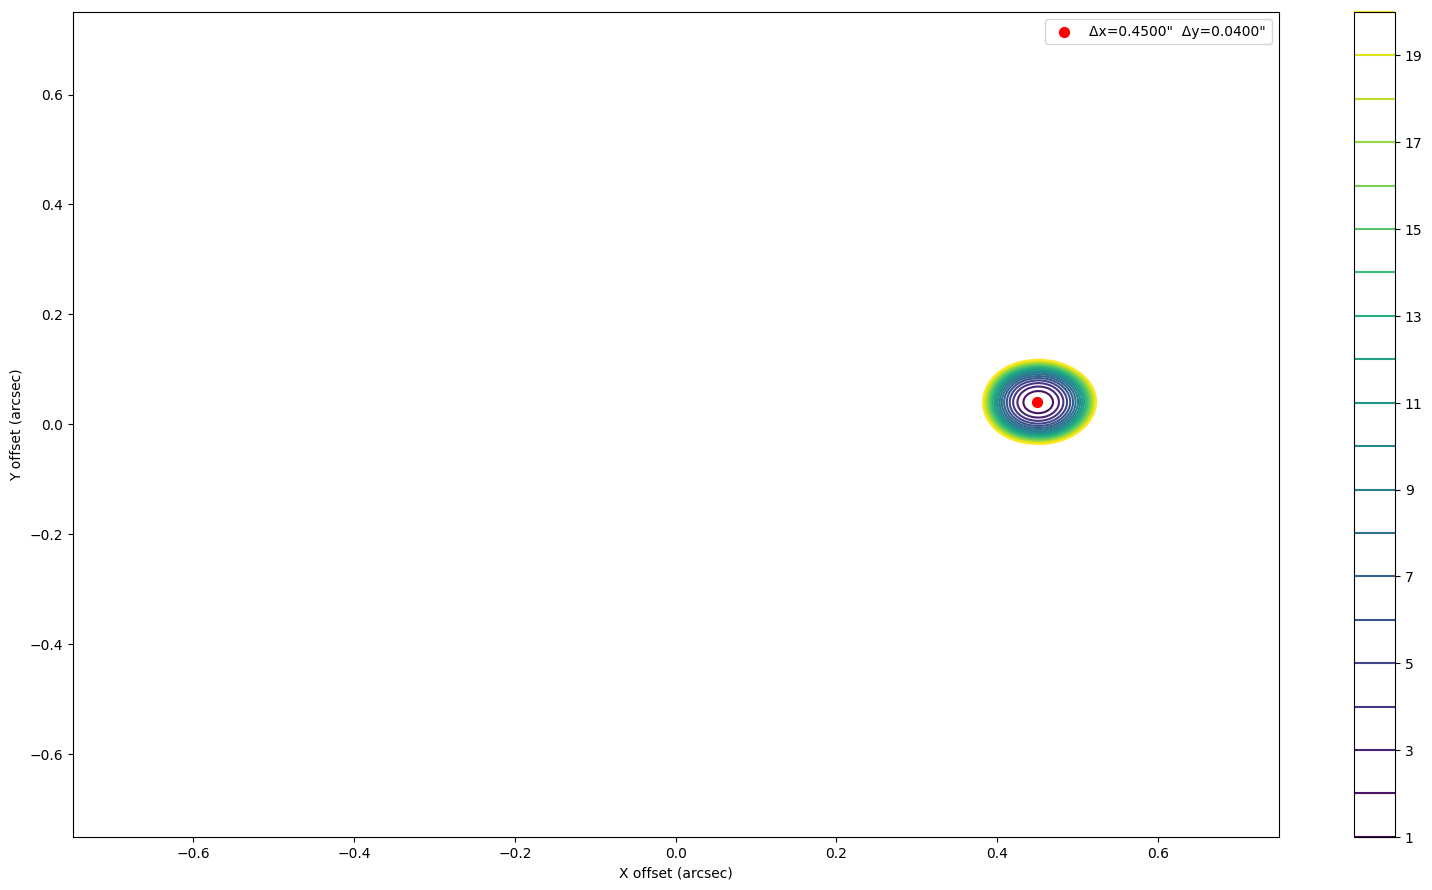

100%|██████████| 90601/90601 [00:12<00:00, 7043.15it/s]


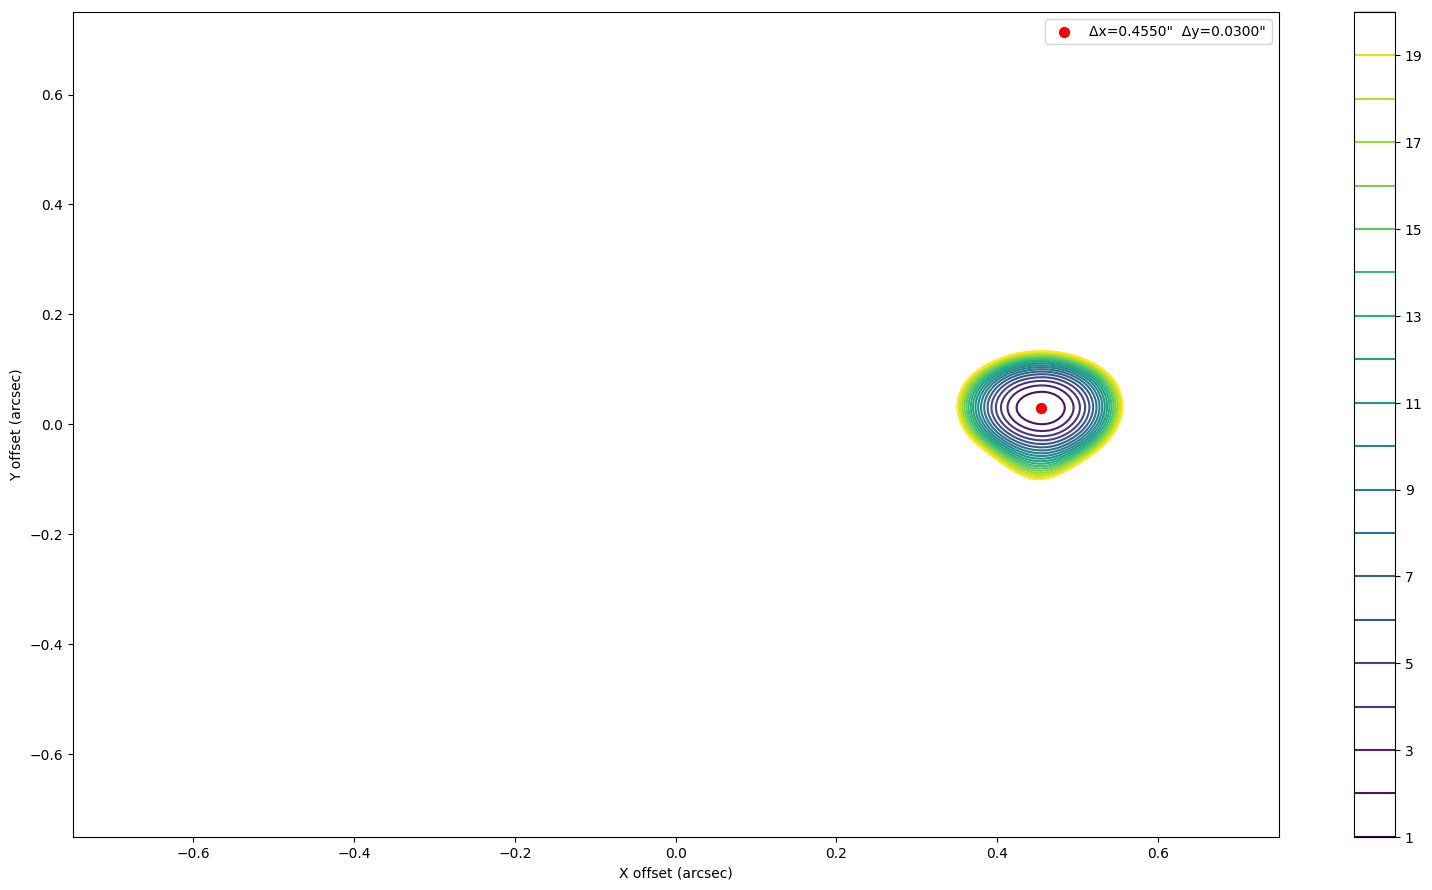

100%|██████████| 90601/90601 [00:12<00:00, 7132.57it/s]


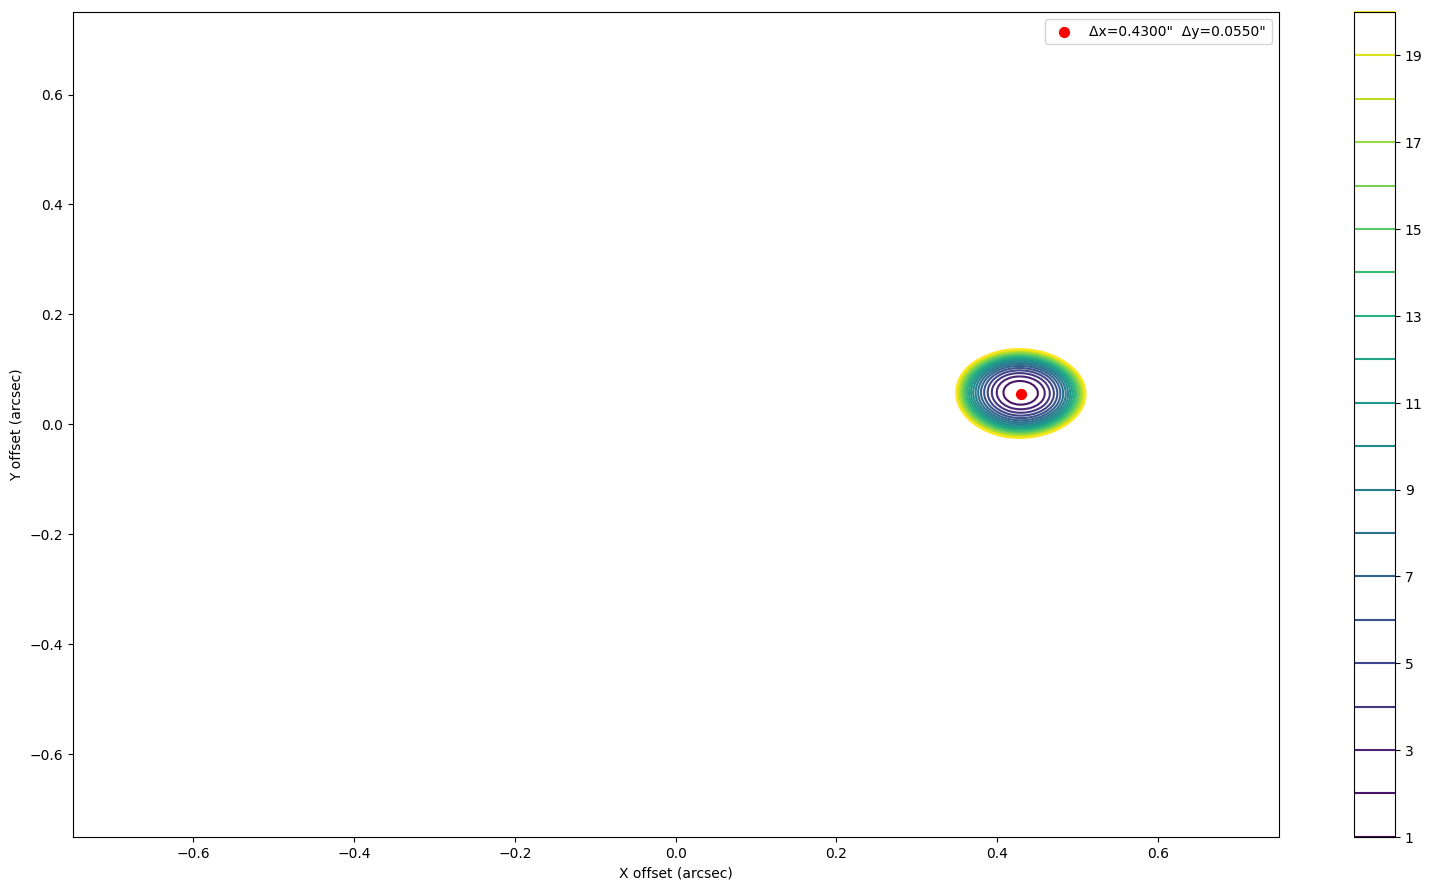

100%|██████████| 90601/90601 [00:13<00:00, 6708.57it/s]


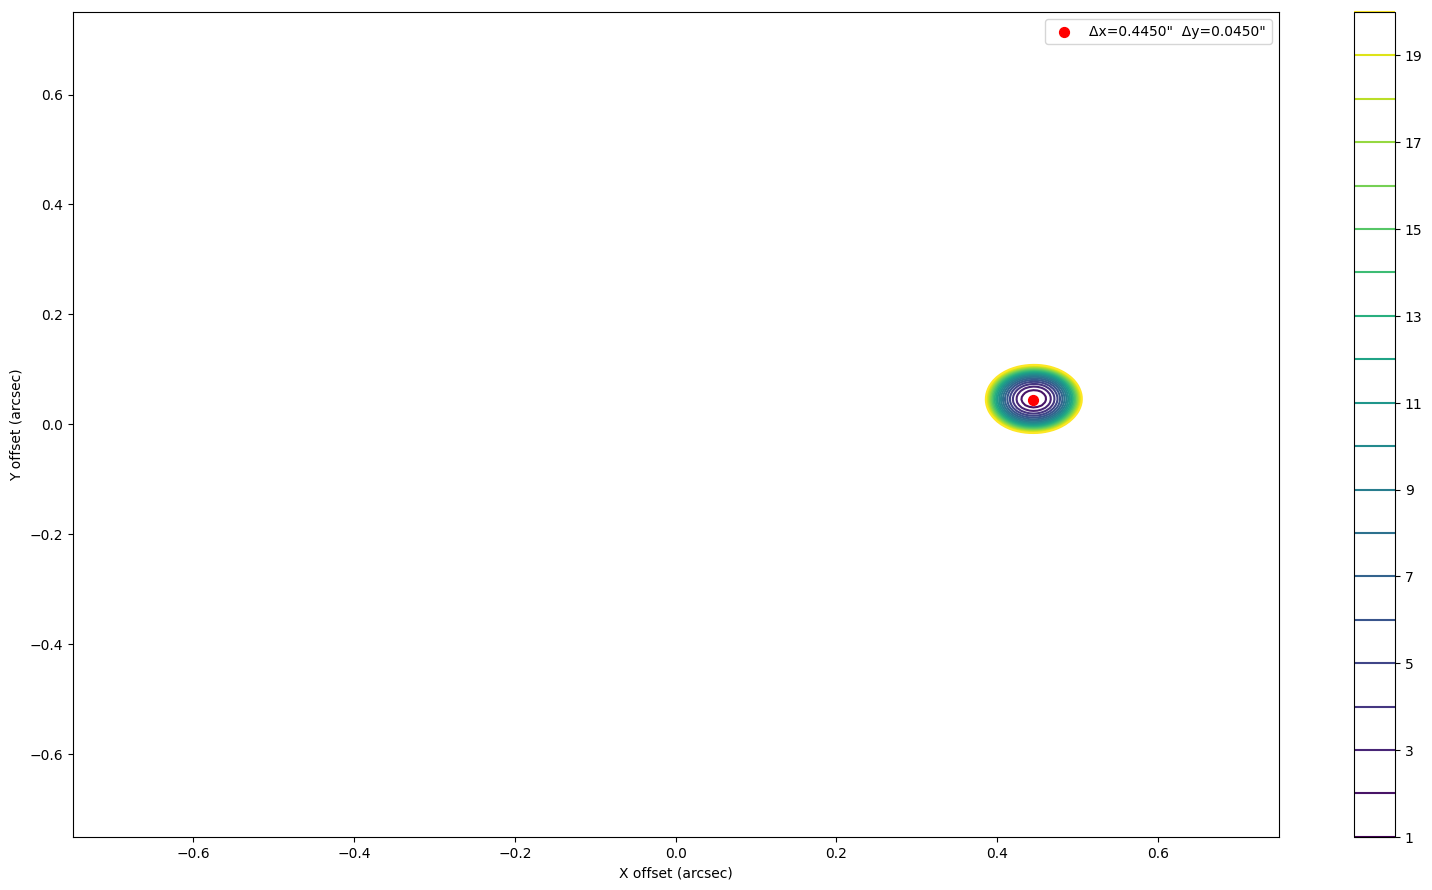

100%|██████████| 90601/90601 [00:12<00:00, 7199.41it/s]


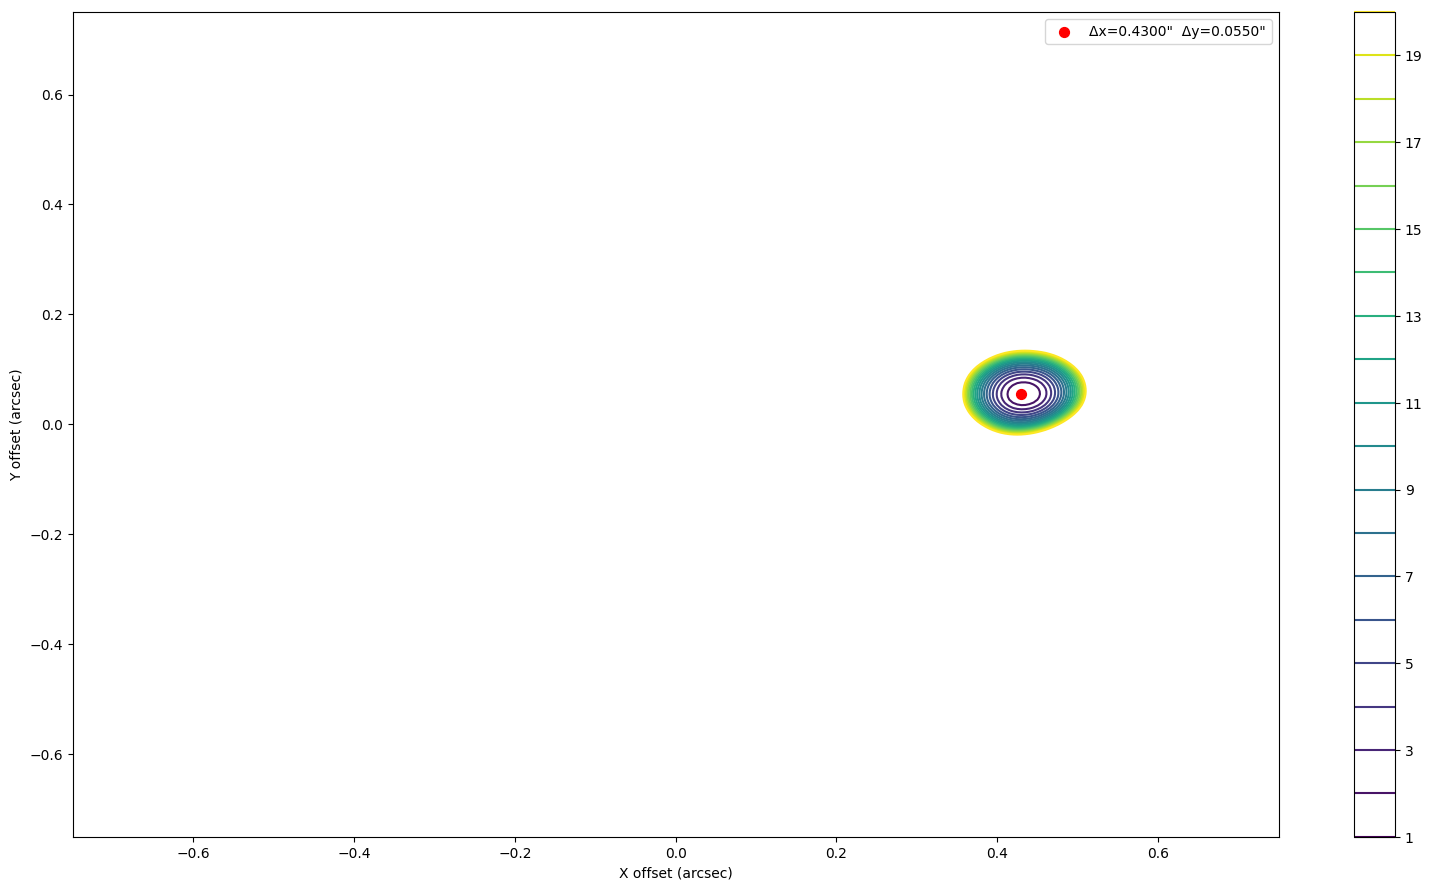

100%|██████████| 90601/90601 [00:12<00:00, 7085.64it/s]


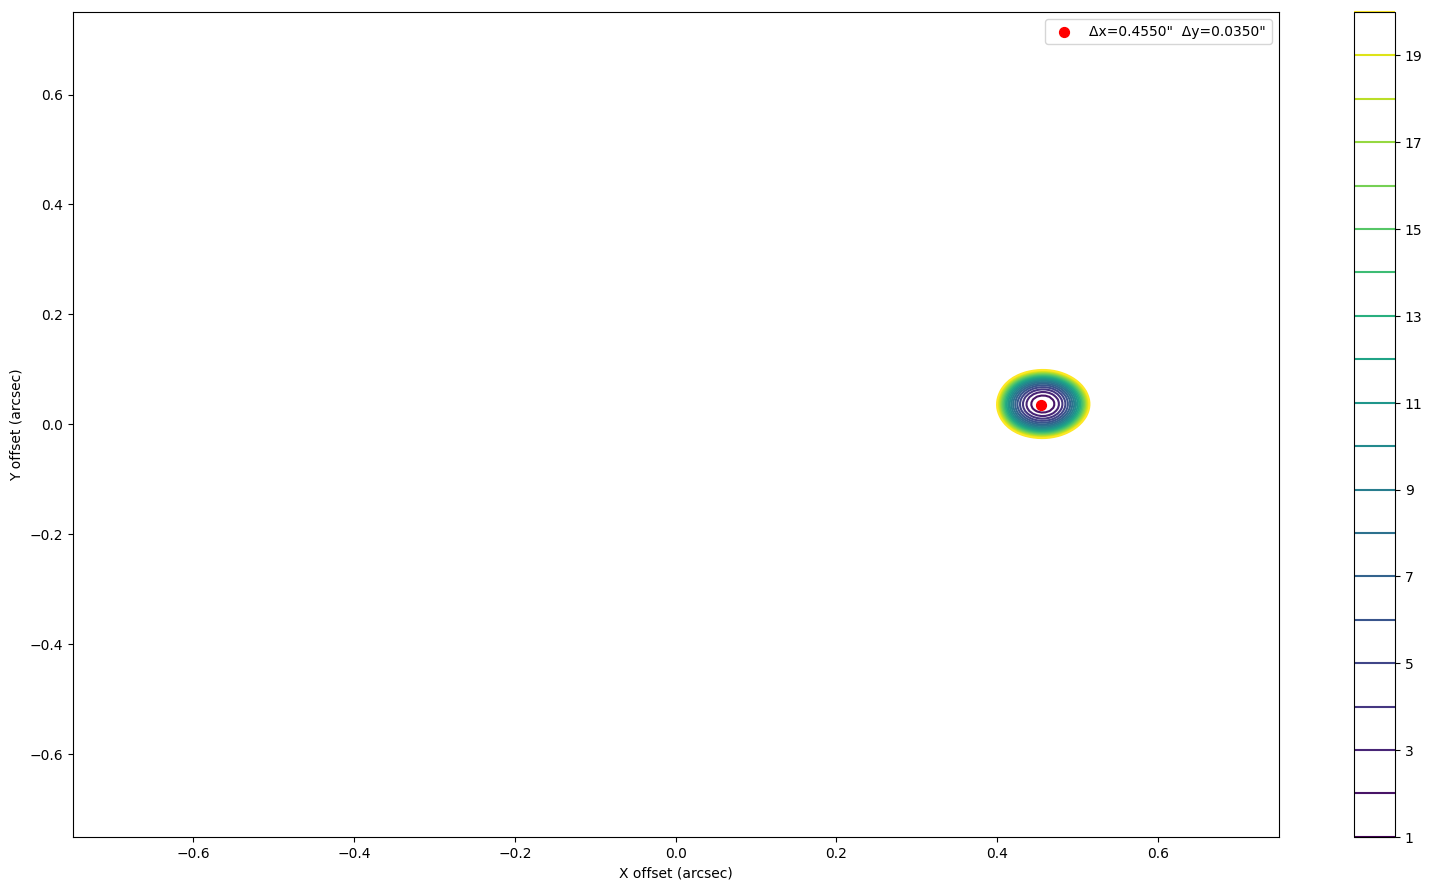

100%|██████████| 90601/90601 [00:12<00:00, 7197.51it/s]


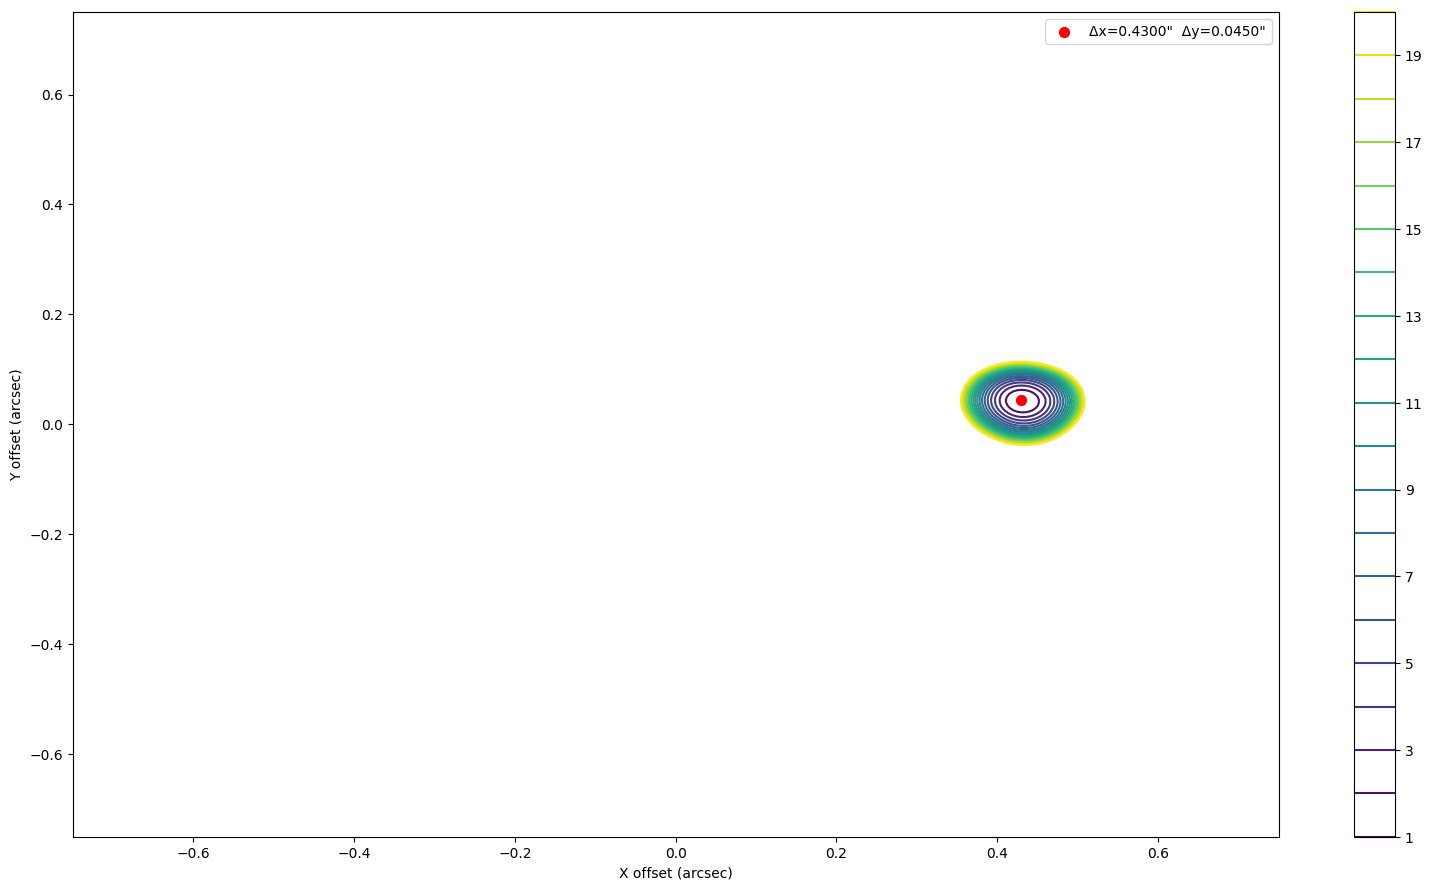

100%|██████████| 90601/90601 [00:13<00:00, 6945.66it/s]


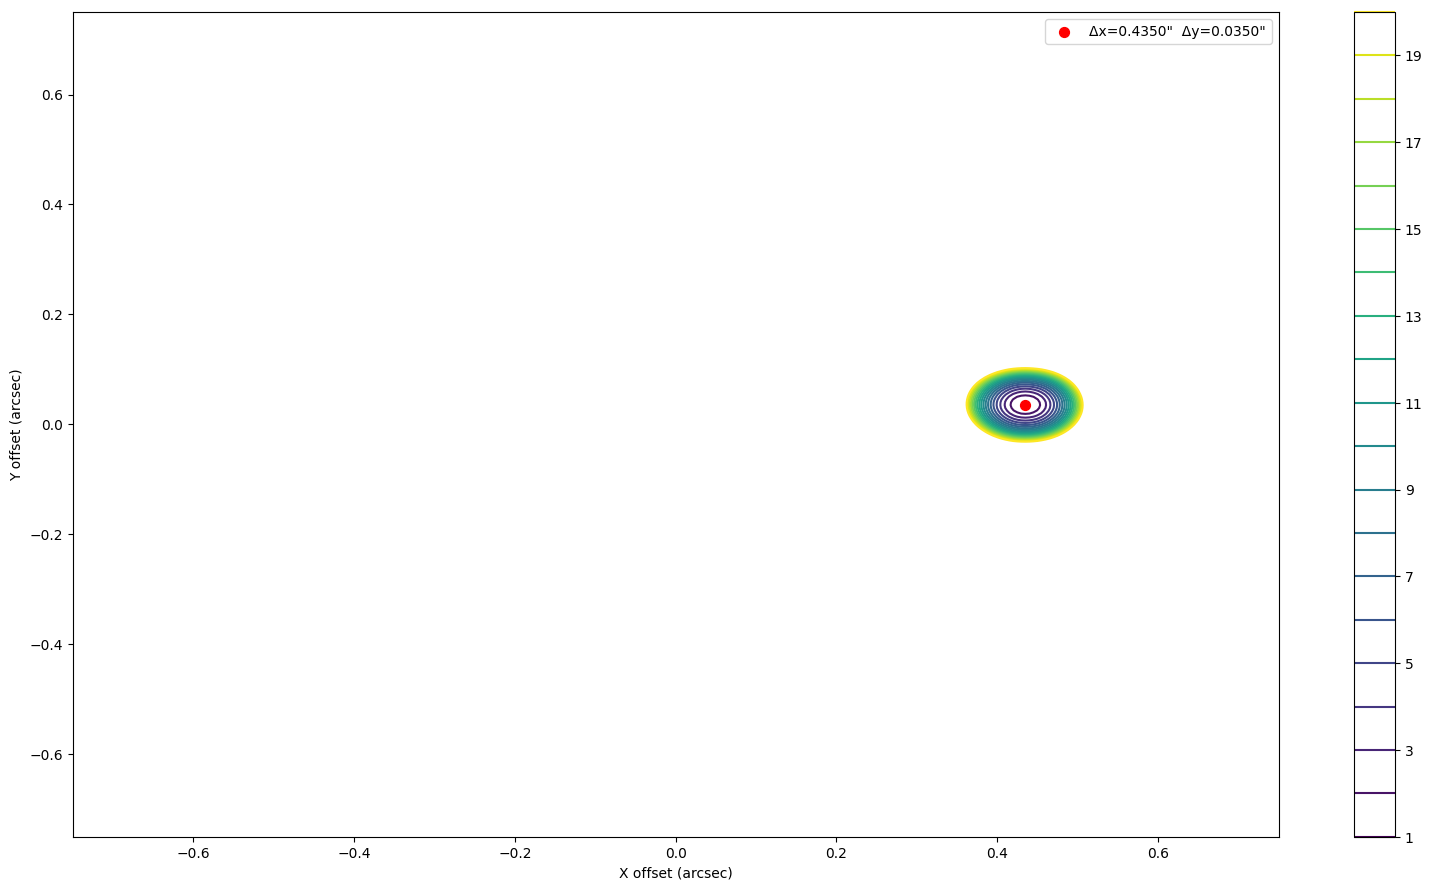

100%|██████████| 90601/90601 [00:12<00:00, 7052.71it/s]


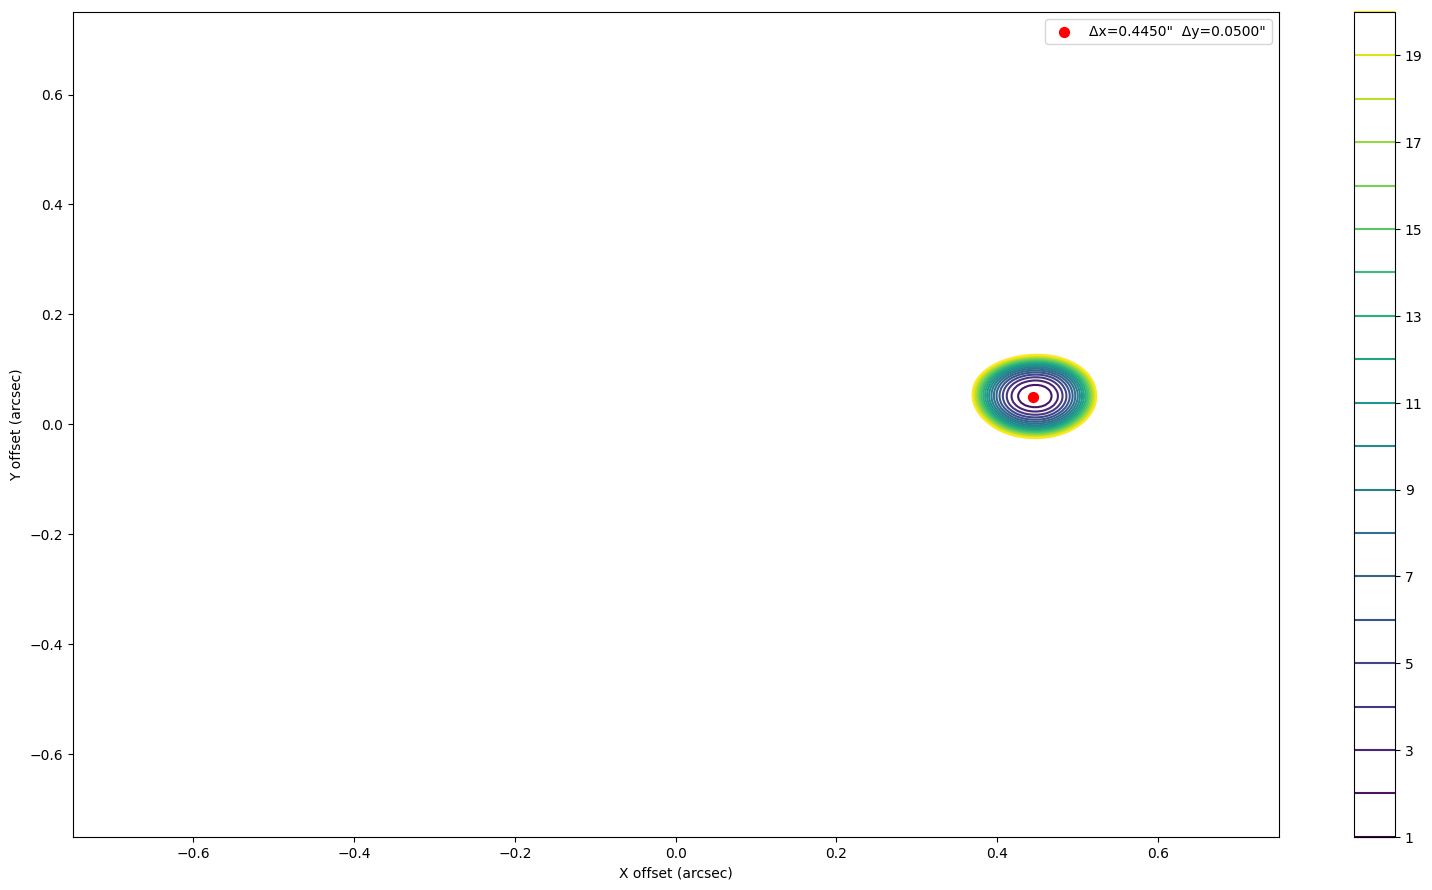

100%|██████████| 90601/90601 [00:12<00:00, 7116.22it/s]


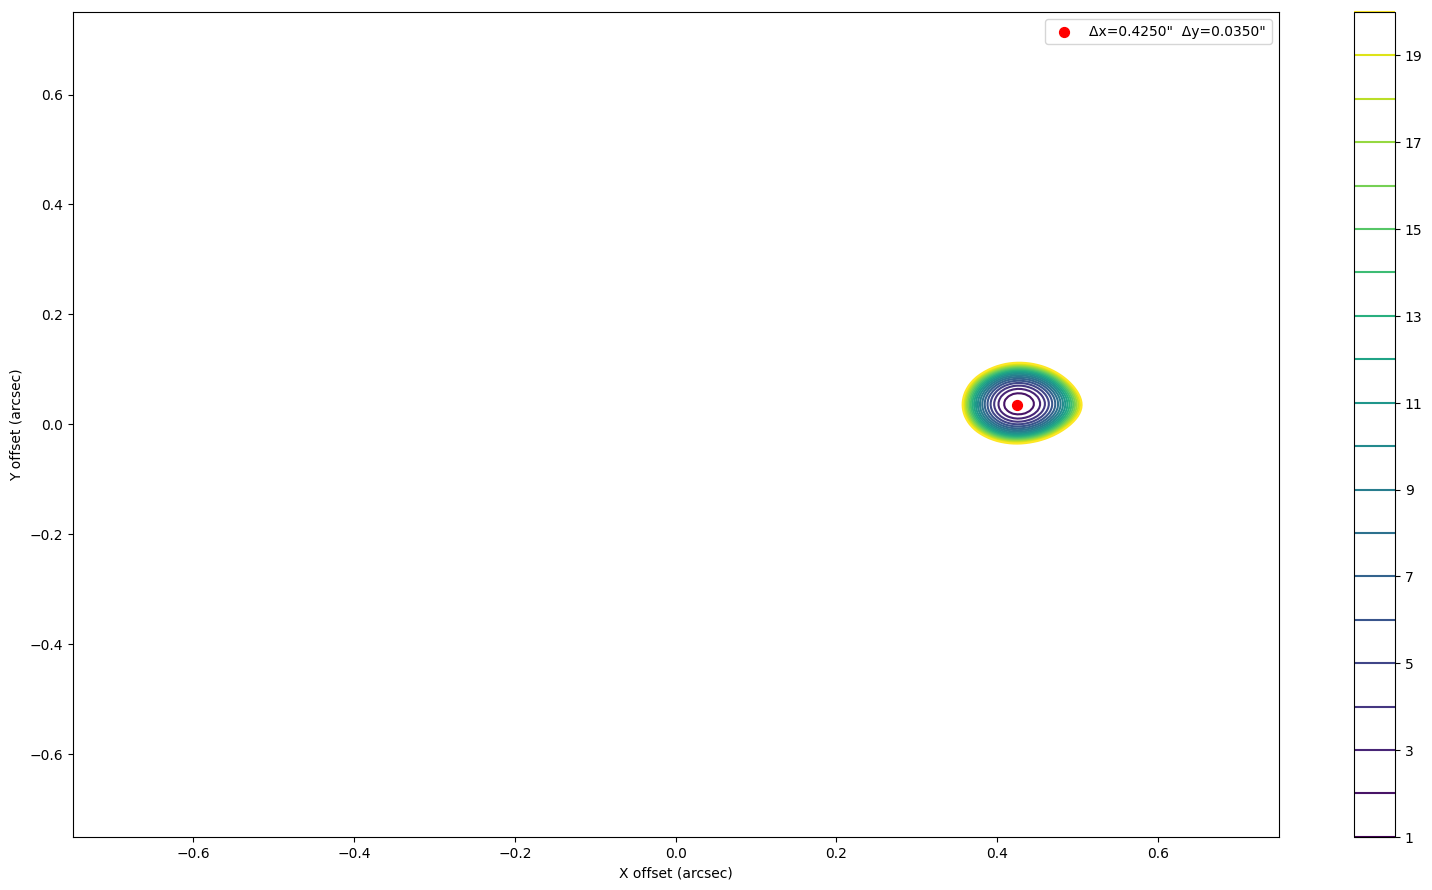

100%|██████████| 90601/90601 [00:12<00:00, 7240.18it/s]


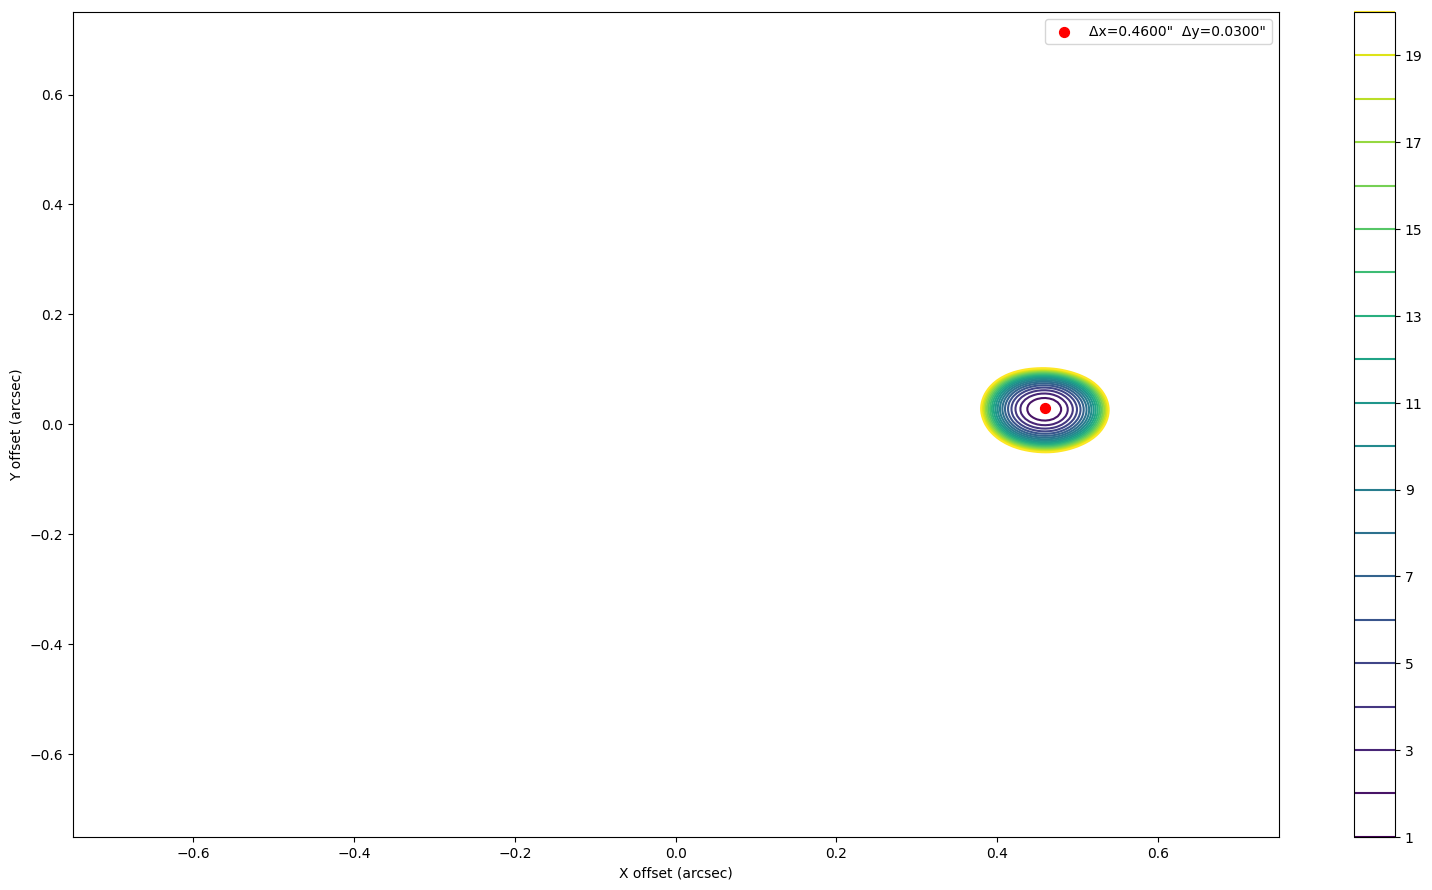

100%|██████████| 90601/90601 [00:12<00:00, 7277.41it/s]


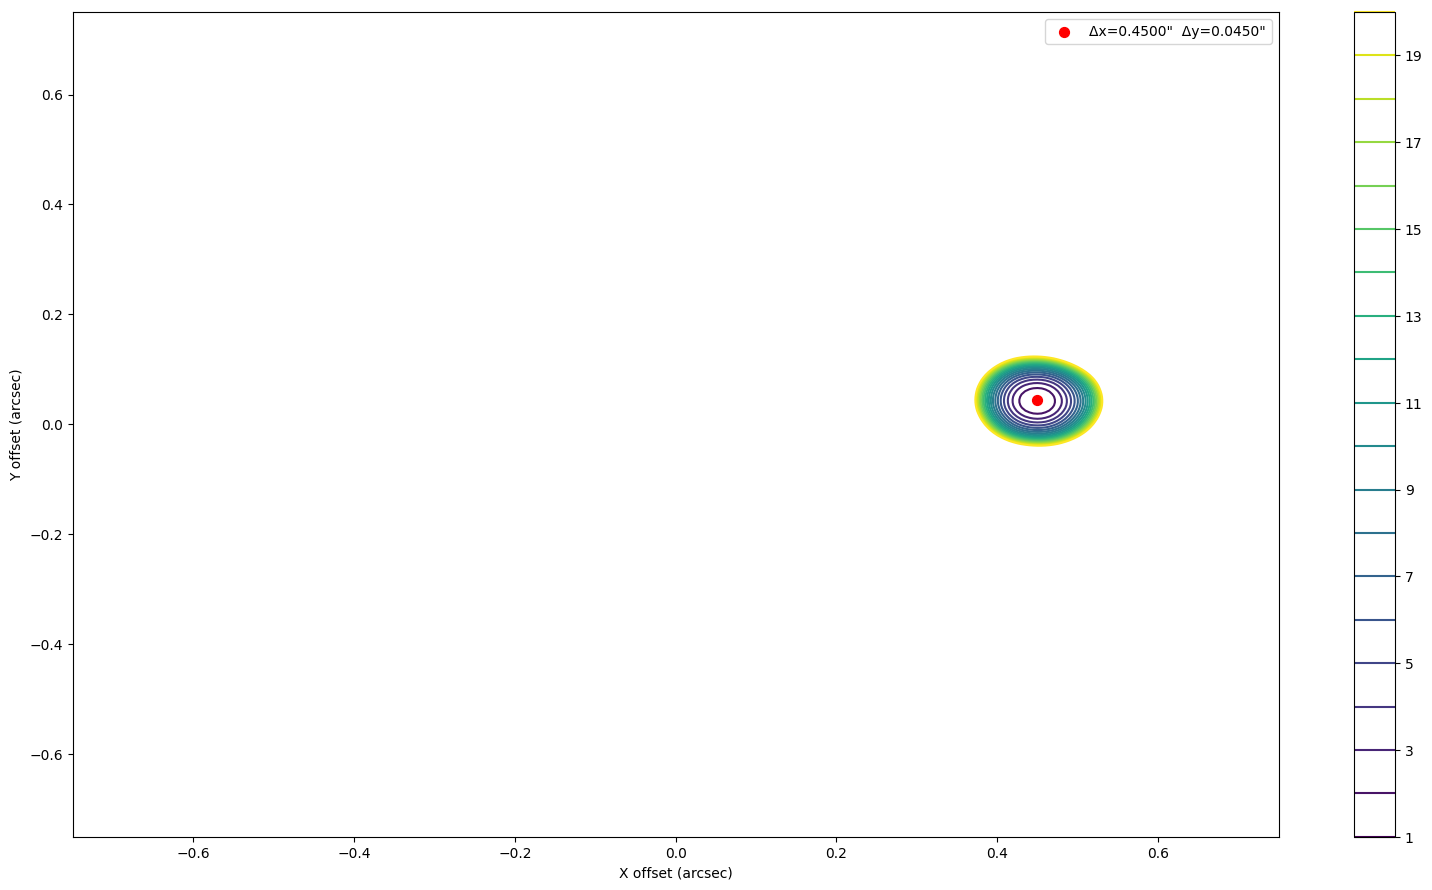

In [6]:
shift_amount = .005 # arcseconds
test_size = 150

min_value = []
best_x = []
best_y = []
area = []
height_error = []
length_error = []
# number = np.zeros(1)
for k in range(len(x_coords)):
    best_idx, best_dx, best_dy, error_area, h_error, w_error = better_psf_fitting(file, header, shift_amount, test_size, gaia_star_field[k])
    min_value.append(best_idx)
    best_x.append(best_dx)
    best_y.append(best_dy)
    area.append(error_area)
    height_error.append(h_error)
    length_error.append(w_error)

In [19]:
print (len(best_y))
best_x = np.array(best_x)
best_y = np.array(best_y)
x_coords = np.array(x_coords)
y_coords = np.array(y_coords)
min_value = np.array(min_value)
area = np.array(area)
height_error = np.array(height_error)
length_error = np.array(length_error)

masked_best_x, masked_best_y, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords = sigma_clip(best_x, best_y, min_value, area, height_error, length_error, x_coords, y_coords, threshold = 3)
print (len(masked_best_y))
masked_best_y, masked_best_x, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords = sigma_clip(masked_best_y, masked_best_x, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords, threshold = 3)

print (len(masked_best_y))

12
12
12


In [ ]:
print ((np.std(masked_best_x) / np.sqrt(len(masked_best_x)))*1000)

3.307189138830741


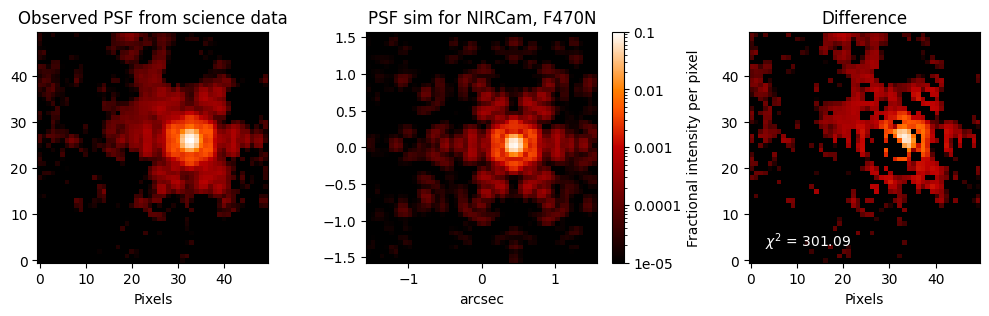

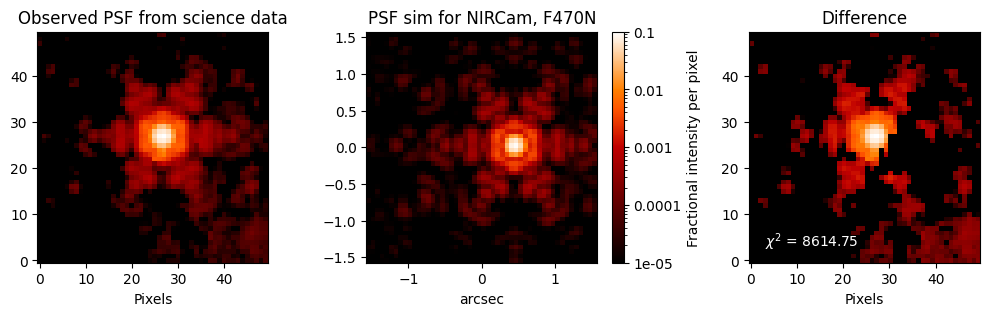

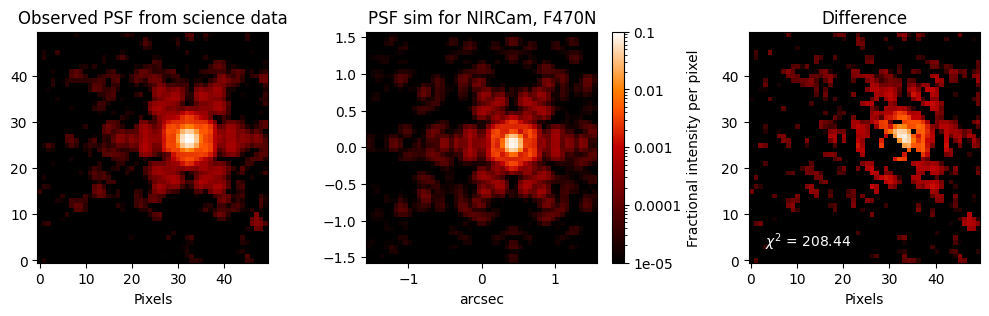

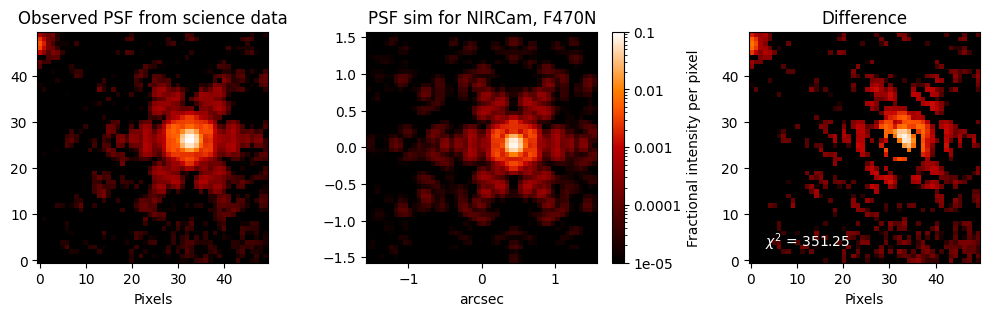

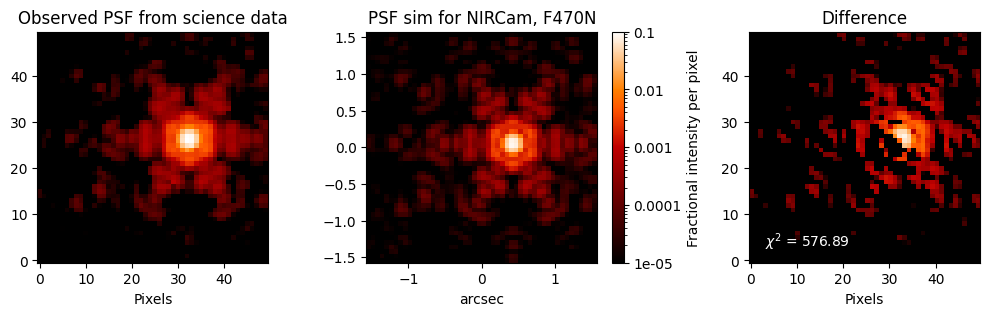

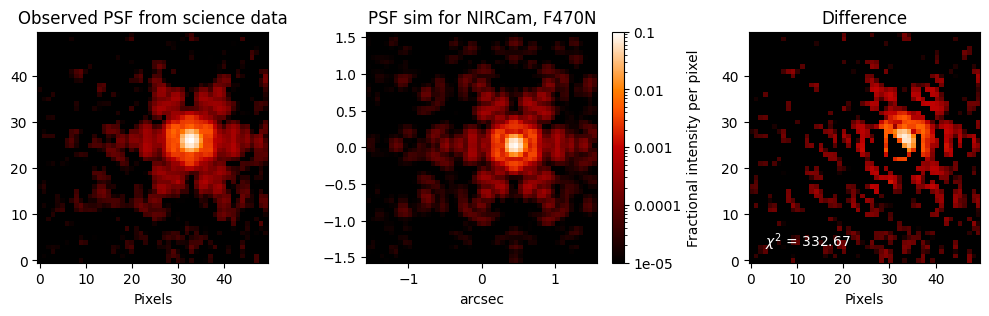

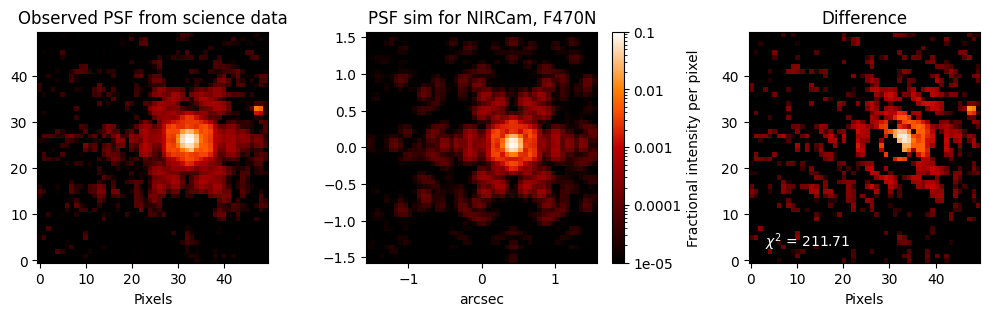

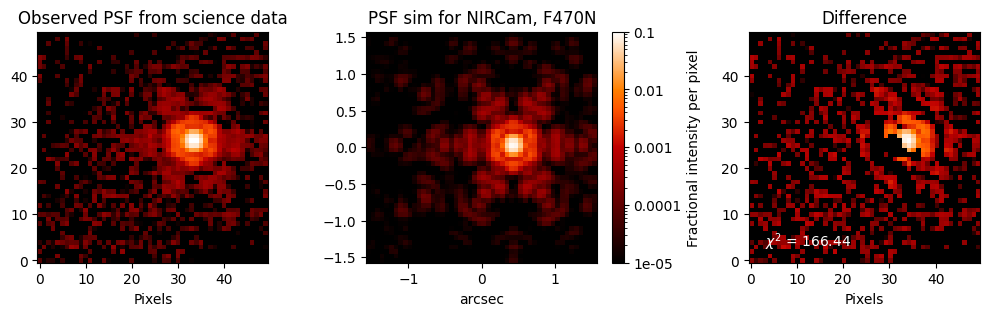

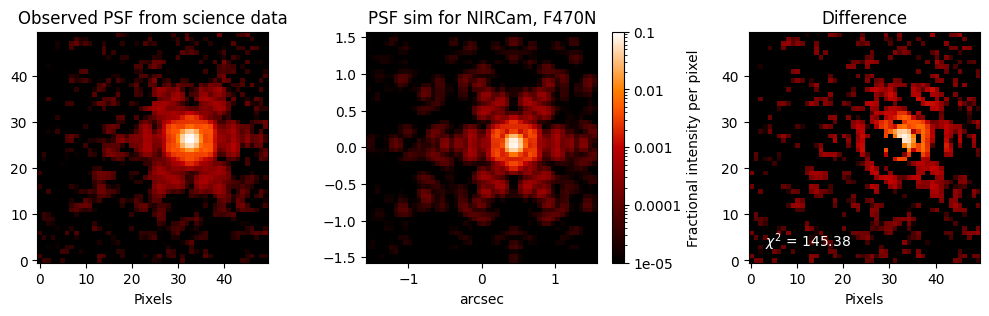

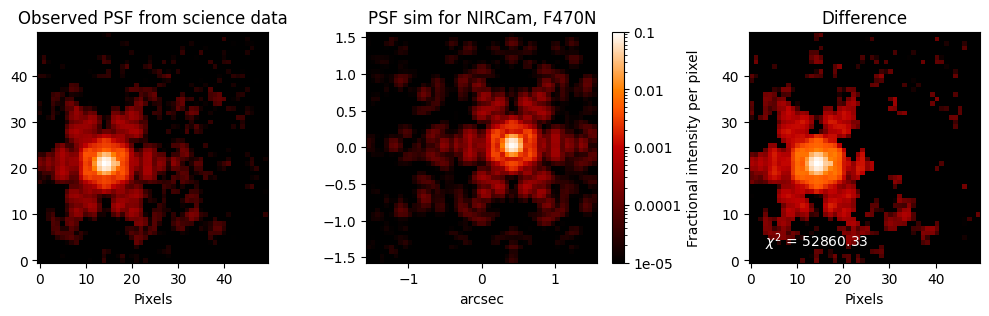

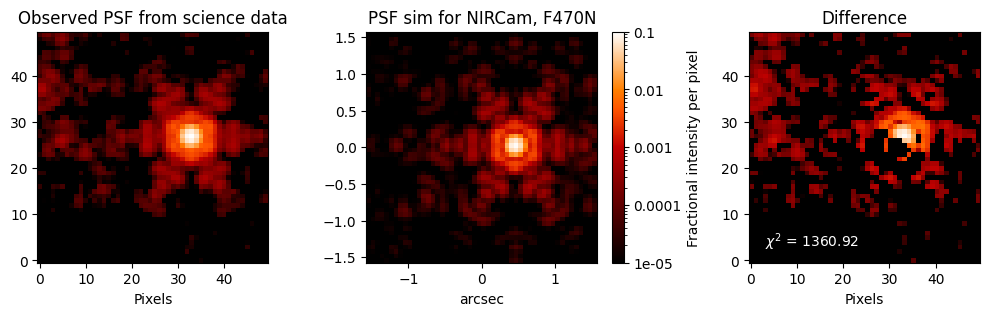

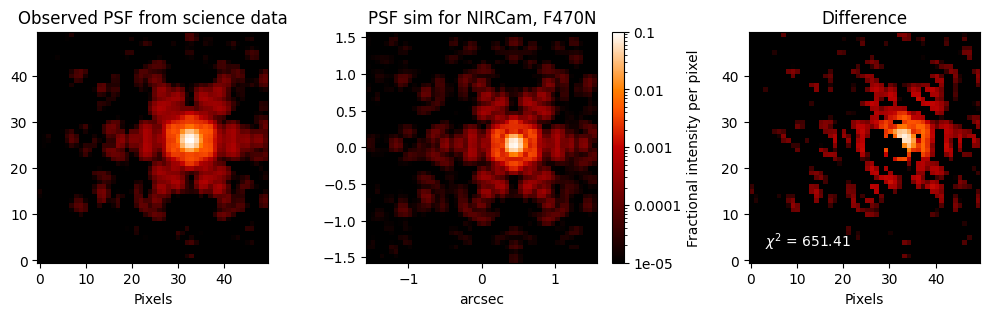

In [9]:
for k in range(len(masked_best_x)):
    psf_center = (masked_x_coords[k], masked_y_coords[k])
    boxsize = 50
    inst = stpsf.setup_sim_to_match_file(file, verbose= False)

    # Load that science data. Cut out the surface brightness and uncertainty for the desired location
    obs_im = fits.open(file)

    obs_psf = Cutout2D(obs_im['SCI'].data, position=psf_center, size=boxsize).data
    obs_psf_err = Cutout2D(obs_im['ERR'].data, position=psf_center, size=boxsize).data

    obs_psf -= np.nanmedian(obs_psf)    # perform a simple background subtraction) 

    inst.options['source_offset_x'] = masked_best_x[k]   # in units of arcseconds. So, this is about 1/5 of a NRC LW pixel
    inst.options['source_offset_y'] = masked_best_y[k]
    sim_psf_offset = inst.calc_psf(fov_pixels=boxsize)

    plot_data_sim_comparison(obs_psf, obs_psf_err, sim_psf_offset)

In [10]:
x_shift = np.mean(masked_best_x)
y_shift = np.mean(masked_best_y)
x_shift_pixel = x_shift / (header['CDELT1']*3600) 
y_shift_pixel = y_shift / (header['CDELT2']*3600)
print (x_shift_pixel, y_shift_pixel)
header['CRPIX1'] += x_shift_pixel
header['CRPIX2'] += y_shift_pixel

7.031258727316852 0.6620770929676884


In [11]:
hdu.writeto(path_image +'gaia-centered-nan-rm-jwst-2025-f444w-f470n.fits', overwrite=True)

In [20]:
hdu = fits.open((path_image + 'gaia-centered-nan-rm-jwst-2025-f444w-f470n.fits'))

INFO: Query finished. [astroquery.utils.tap.core]


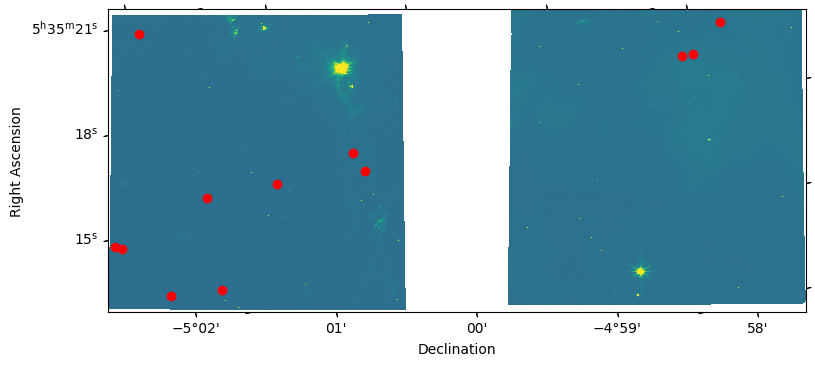

In [21]:
ra_center = hdu[1].header['CRVAL1']
dec_center = hdu[1].header['CRVAL2']
size_deg = .1
image = hdu[1].data
header = hdu[1].header

x_coords, y_coords, l = find_stars(ra_center, dec_center, size_deg, image, header)

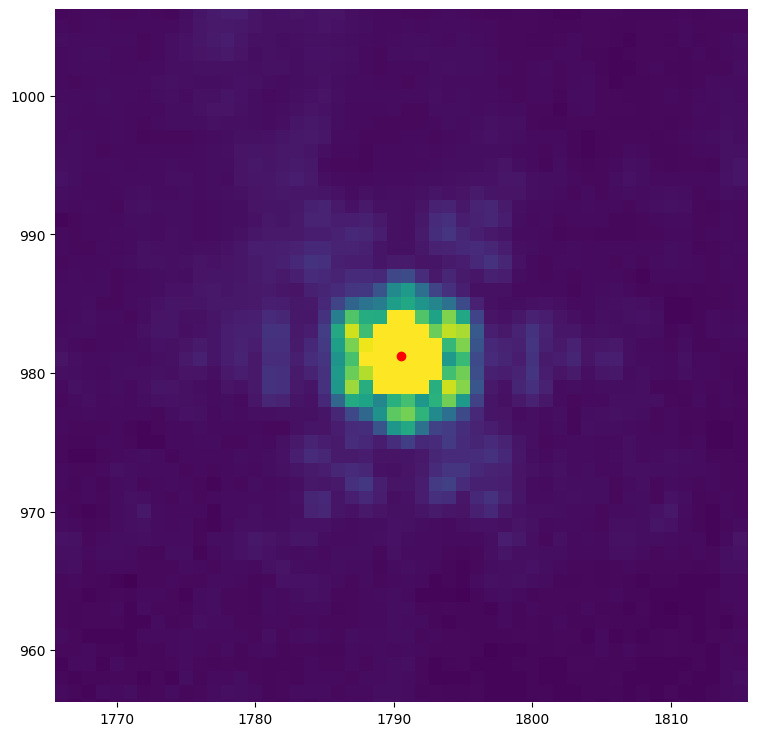

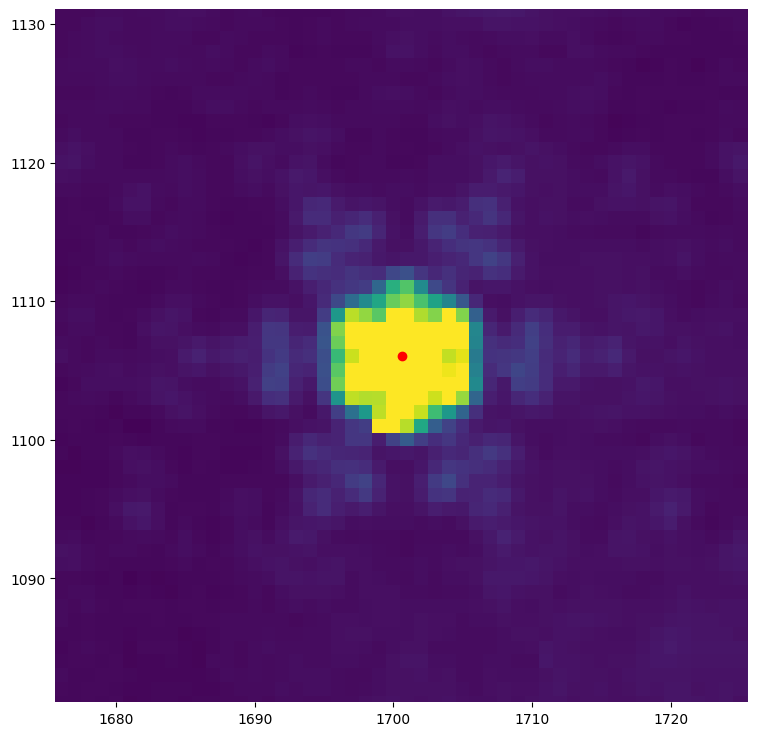

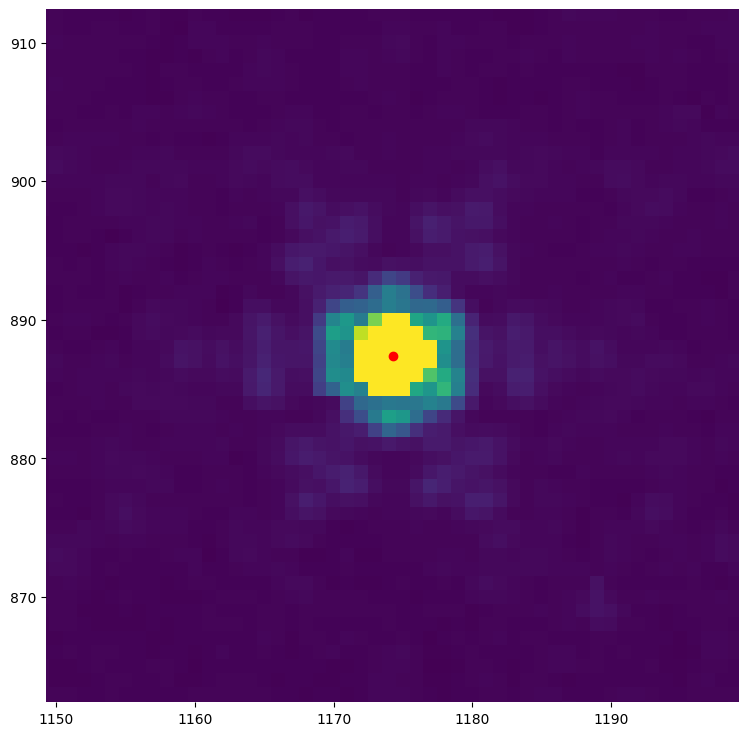

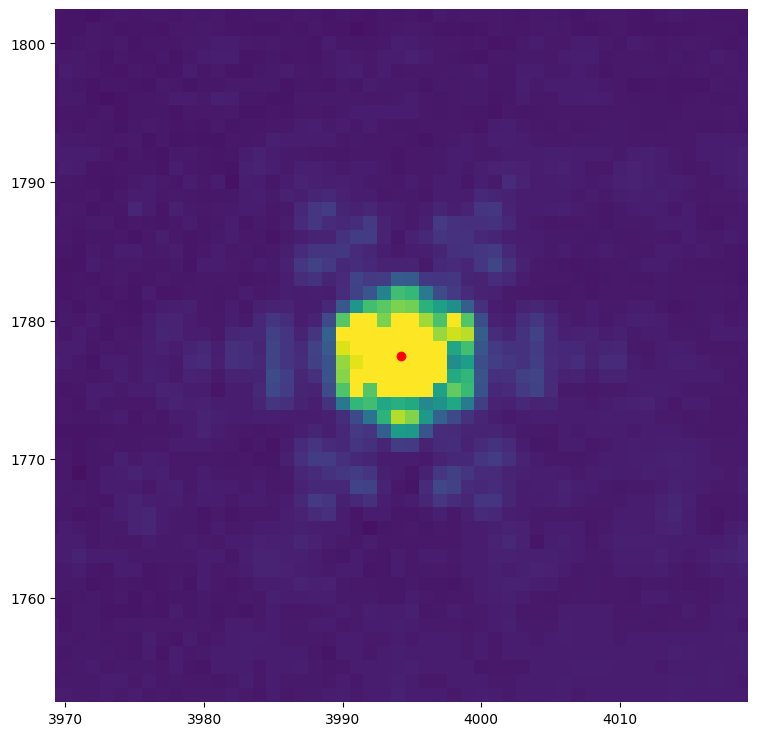

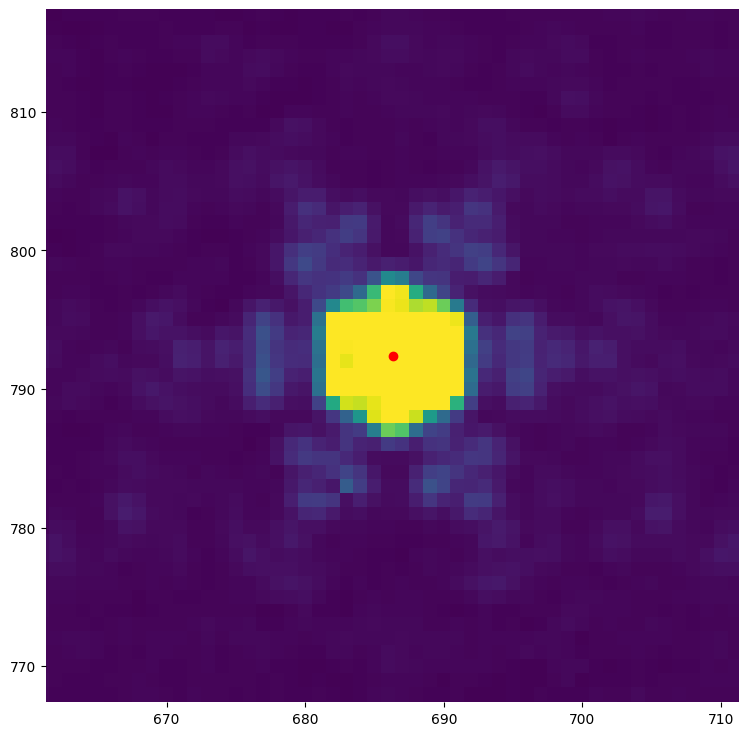

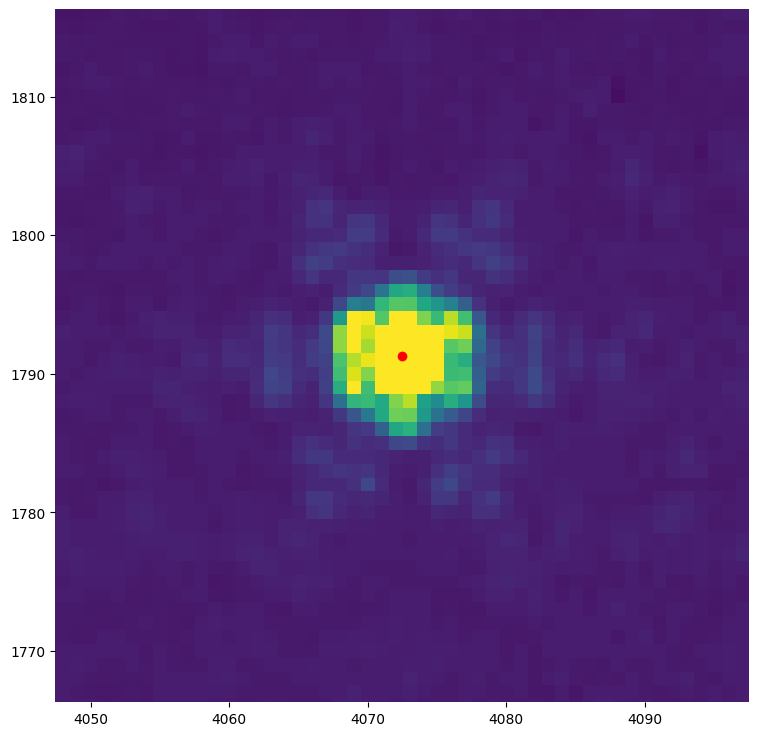

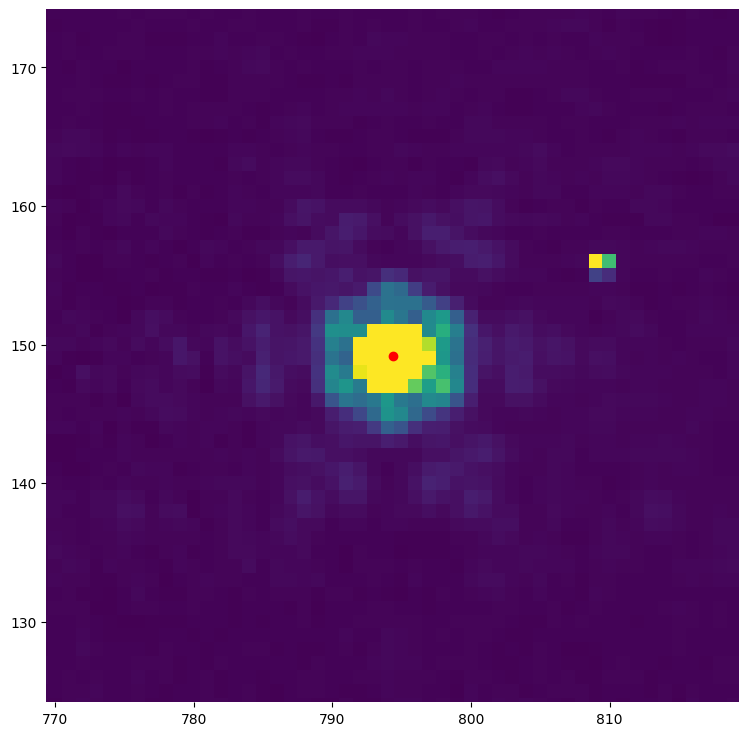

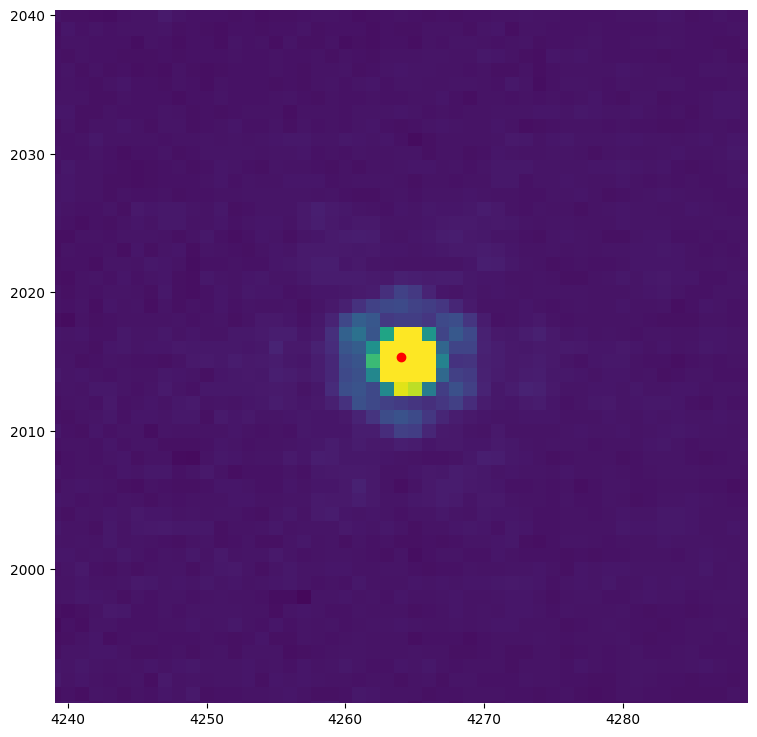

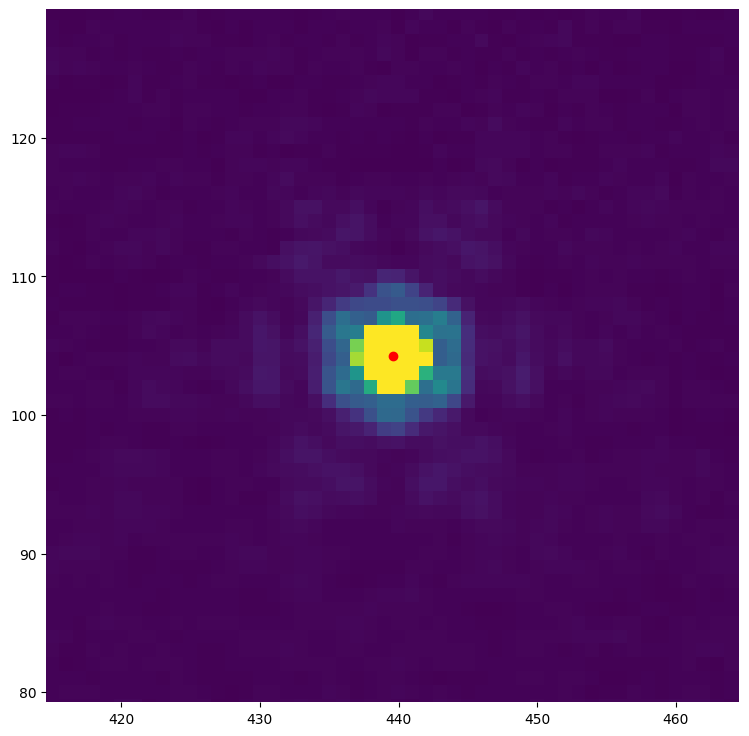

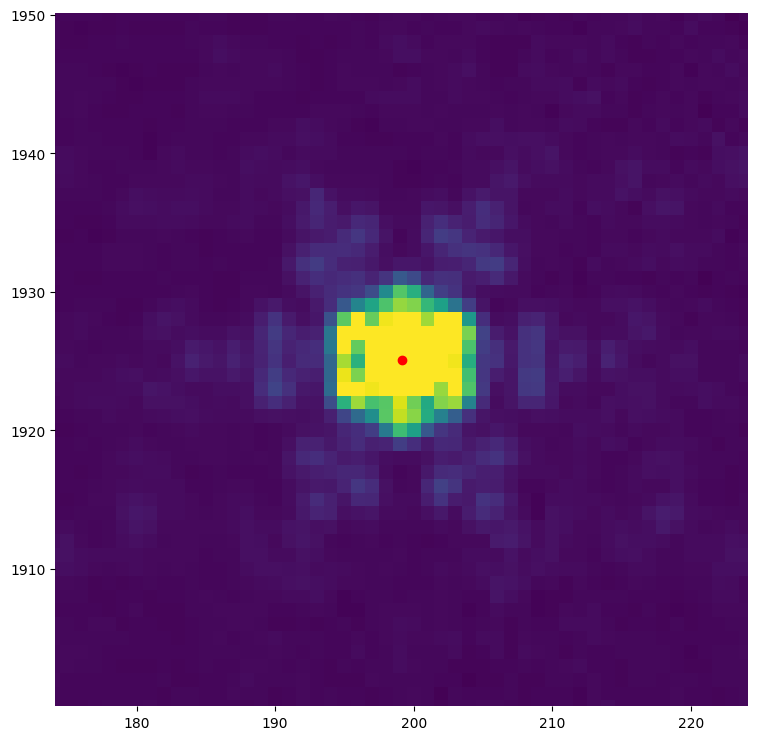

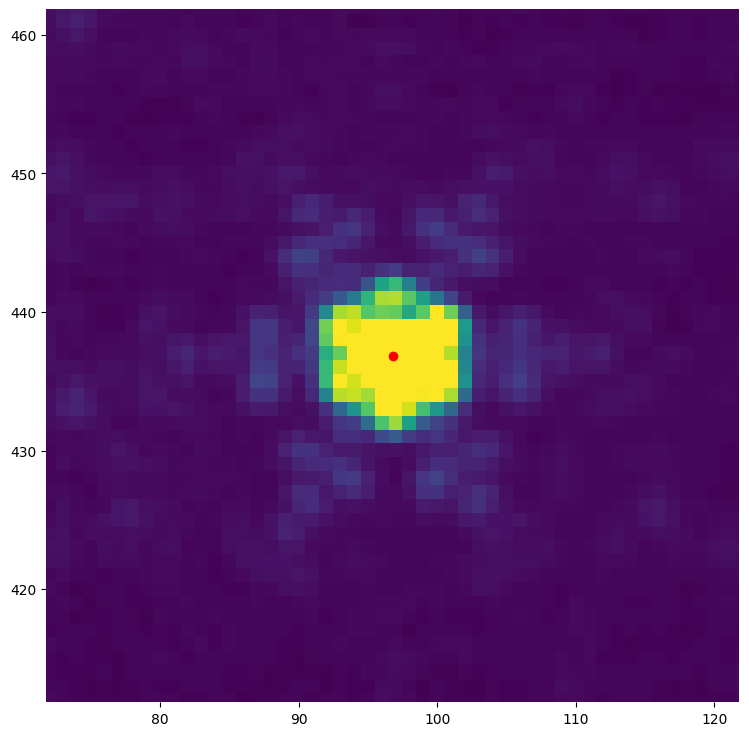

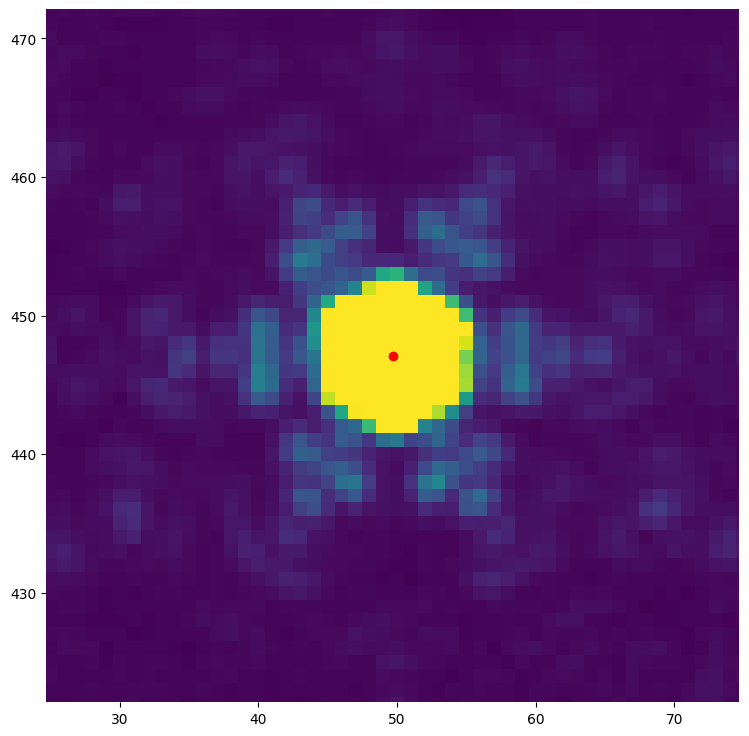

In [22]:
star_check(image, header, gaia_star_field)